# Cross-City LVT Analysis

Loads standardized CSVs from all cities and compares LVT impacts.
No modeling or API calls — just reads `analysis/data/*.csv`.

Run after running each city's `model.ipynb` to update the CSVs.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from lvt.style import apply_lvt_style, CATEGORY_COLORS, INCREASE_COLOR, DECREASE_COLOR
apply_lvt_style()

DATA_DIR = Path('data')

# Load all city CSVs
dfs = []
for csv_path in sorted(DATA_DIR.glob('*.csv')):
    if csv_path.name == '.gitkeep':
        continue
    try:
        df = pd.read_csv(csv_path)
        dfs.append(df)
        print(f'  {csv_path.stem}: {len(df):,} rows')
    except Exception as e:
        print(f'  ERROR {csv_path.stem}: {e}')

if not dfs:
    raise RuntimeError('No city CSVs found in analysis/data/. Run city notebooks first.')

all_cities = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(all_cities):,} parcels across {all_cities["city"].nunique()} cities')
print(all_cities['city'].value_counts().to_string())

  baltimore: 238,442 rows
  bellingham: 41,032 rows
  bryan: 30,496 rows
  charlottesville: 15,165 rows


  cleveland: 158,448 rows
  college_station: 28,158 rows
  fort_collins: 70,553 rows


  greeley: 33,184 rows
  highlands_ranch: 16,185 rows
  newport_news: 54,472 rows
  oak_forest: 10,701 rows


  philadelphia: 579,814 rows


  philadelphia_lycd: 579,814 rows


  philadelphia_lycd_post_abatement: 579,814 rows


  philadelphia_post_abatement: 579,814 rows
  pueblo: 47,167 rows
  reading: 26,299 rows
  richmond: 76,879 rows


  roanoke: 44,441 rows
  rochester: 57,628 rows
  southbend: 44,324 rows


  st_paul: 72,437 rows
  syracuse: 41,697 rows

Total: 3,426,964 parcels across 23 cities
city
philadelphia                        579814
philadelphia_lycd                   579814
philadelphia_lycd_post_abatement    579814
philadelphia_post_abatement         579814
baltimore                           238442
cleveland                           158448
richmond                             76879
st_paul                              72437
fort_collins                         70553
rochester                            57628
newport_news                         54472
pueblo                               47167
roanoke                              44441
southbend                            44324
syracuse                             41697
bellingham                           41032
greeley                              33184
bryan                                30496
college_station                      28158
reading                              26299
highlands_ranch                      16185
ch

## 1. Revenue and Parcel Summary

In [2]:
# Revenue and parcel count summary by city
summary = all_cities.groupby('city').agg(
    parcel_count=('current_tax', 'count'),
    taxable_parcels=('current_tax', lambda x: (x > 0).sum()),
    current_revenue=('current_tax', 'sum'),
    new_revenue=('new_tax', 'sum'),
    model_type=('model_type', 'first'),
    land_millage=('land_millage', 'first'),
    improvement_millage=('improvement_millage', 'first'),
).reset_index()

summary['revenue_neutral_pct'] = (
    (summary['new_revenue'] - summary['current_revenue']).abs() /
    summary['current_revenue'] * 100
).round(3)

summary['current_revenue_M'] = (summary['current_revenue'] / 1e6).round(1)
summary['new_revenue_M'] = (summary['new_revenue'] / 1e6).round(1)

display_cols = [
    'city', 'parcel_count', 'taxable_parcels', 'current_revenue_M',
    'new_revenue_M', 'revenue_neutral_pct', 'model_type', 'land_millage', 'improvement_millage'
]
print(summary[display_cols].to_string(index=False))

                            city  parcel_count  taxable_parcels  current_revenue_M  new_revenue_M  revenue_neutral_pct                          model_type  land_millage  improvement_millage
                       baltimore        238442           220093             1153.2         1153.2                0.000                      split_rate:4.0    104.544674            26.136169
                      bellingham         41032            41032              264.8          264.8                0.000                      split_rate:4.0     13.964254             3.491064
                           bryan         30496            29644              198.9          198.9                0.000                      split_rate:4.0     45.406438            11.351609
                 charlottesville         15165            15165              119.5          119.5                0.000                      split_rate:4.0     20.812376             5.203094
                       cleveland        158448    

## 2. Tax Change Distribution by City

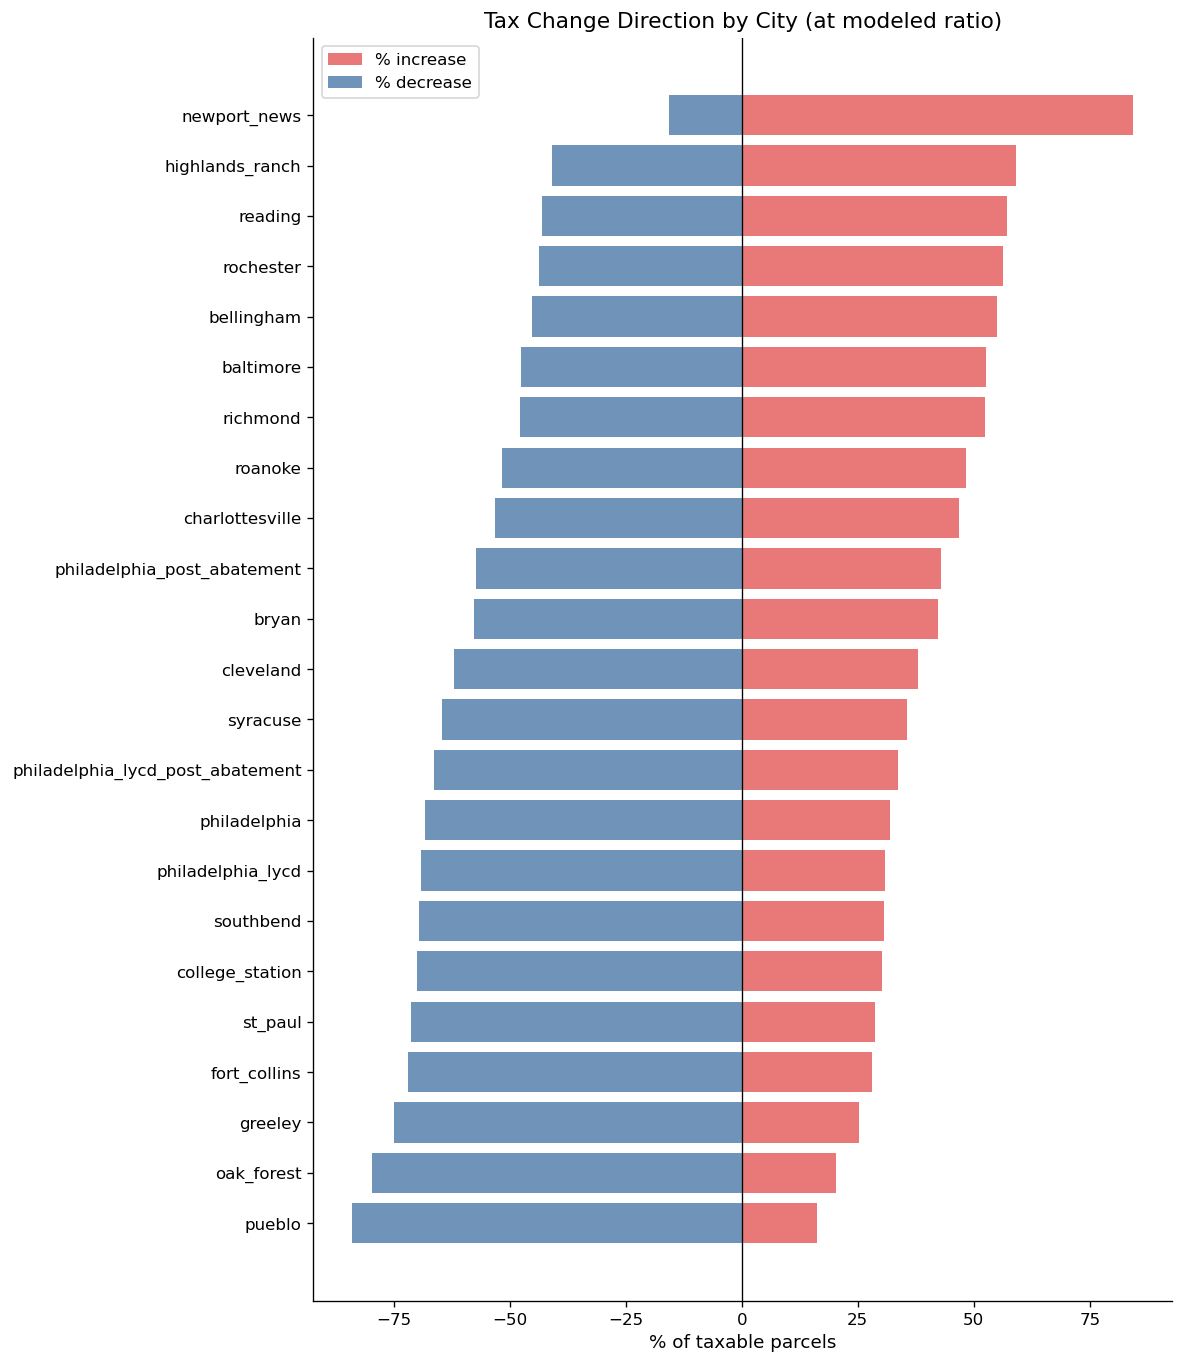

                            city  pct_increase  pct_decrease  median_change_pct
                          pueblo     16.134035     83.865965         -11.637704
                      oak_forest     20.358701     79.621910          -9.844331
                         greeley     25.154980     74.845020          -6.151448
                    fort_collins     28.153303     71.807010         -13.521485
                         st_paul     28.757303     71.242697         -12.878358
                 college_station     30.140917     69.859083          -9.310521
                       southbend     30.584686     69.415314         -11.009898
               philadelphia_lycd     30.943181     69.056819         -20.332786
                    philadelphia     31.876169     68.123831         -12.658789
philadelphia_lycd_post_abatement     33.639289     66.360711         -14.124210
                        syracuse     35.496865     64.503135          -6.009364
                       cleveland     37.

In [3]:
# % parcels with tax increase, by city (excluding zero-tax parcels)
taxable = all_cities[all_cities['current_tax'] > 0].copy()

direction = taxable.groupby('city').agg(
    pct_increase=('tax_change', lambda x: (x > 0).mean() * 100),
    pct_decrease=('tax_change', lambda x: (x < 0).mean() * 100),
    median_change_pct=('tax_change_pct', 'median'),
).reset_index().sort_values('pct_increase')

fig, ax = plt.subplots(figsize=(10, max(4, len(direction) * 0.5)))
cities = direction['city']
y = range(len(cities))
ax.barh(y, direction['pct_increase'], color=INCREASE_COLOR, alpha=0.8, label='% increase')
ax.barh(y, -direction['pct_decrease'], color=DECREASE_COLOR, alpha=0.8, label='% decrease')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels(cities)
ax.set_xlabel('% of taxable parcels')
ax.set_title('Tax Change Direction by City (at modeled ratio)')
ax.legend()
plt.tight_layout()
plt.show()

print(direction.to_string(index=False))

## 3. Property Category Comparison

Median tax change % by category and city:
property_category                 Commercial  Large Multi-Family (5+ units)  Single Family Residential  Small Multi-Family (2-4 units)  Vacant Land
city                                                                                                                                               
baltimore                                NaN                            2.1                        2.0                            -0.8        151.5
bellingham                               NaN                           -9.5                        NaN                            -2.7         79.6
bryan                                   28.2                          -24.0                       -8.3                            -8.6          NaN
charlottesville                         26.6                           -9.8                       -3.6                             2.4        112.4
cleveland                               -2.3                          

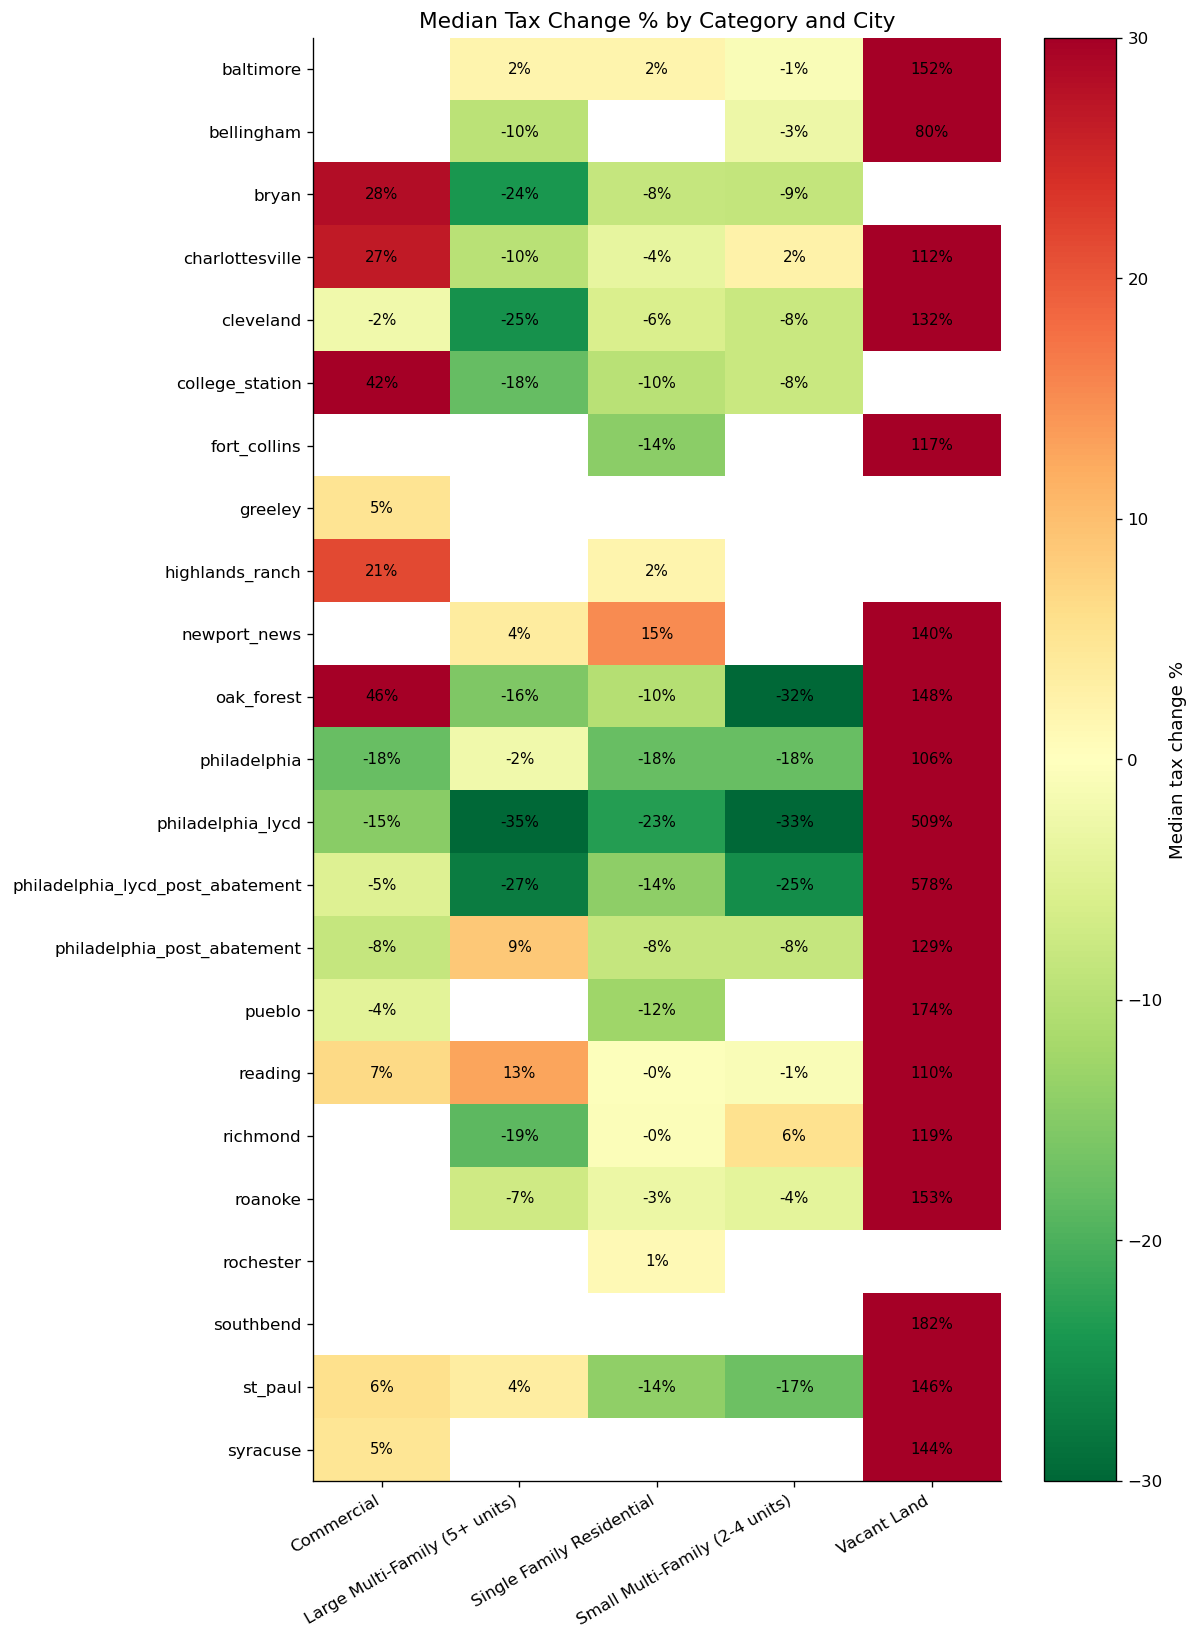

In [4]:
# Median tax change % by property category × city
# Focus on the most common standard categories
focus_cats = [
    'Single Family Residential',
    'Commercial',
    'Vacant Land',
    'Large Multi-Family (5+ units)',
    'Small Multi-Family (2-4 units)',
]

cat_city = (
    taxable[taxable['property_category'].isin(focus_cats)]
    .groupby(['city', 'property_category'])
    ['tax_change_pct']
    .median()
    .unstack('property_category')
    .round(1)
)

print('Median tax change % by category and city:')
print(cat_city.to_string())

# Heatmap
if len(cat_city) > 1:
    fig, ax = plt.subplots(figsize=(max(8, len(cat_city.columns) * 2), max(4, len(cat_city) * 0.6)))
    im = ax.imshow(cat_city.values, cmap='RdYlGn_r', aspect='auto', vmin=-30, vmax=30)
    ax.set_xticks(range(len(cat_city.columns)))
    ax.set_xticklabels(cat_city.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(cat_city.index)))
    ax.set_yticklabels(cat_city.index)
    plt.colorbar(im, ax=ax, label='Median tax change %')
    ax.set_title('Median Tax Change % by Category and City')
    for i in range(len(cat_city.index)):
        for j in range(len(cat_city.columns)):
            val = cat_city.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. Income Quintile Equity Comparison

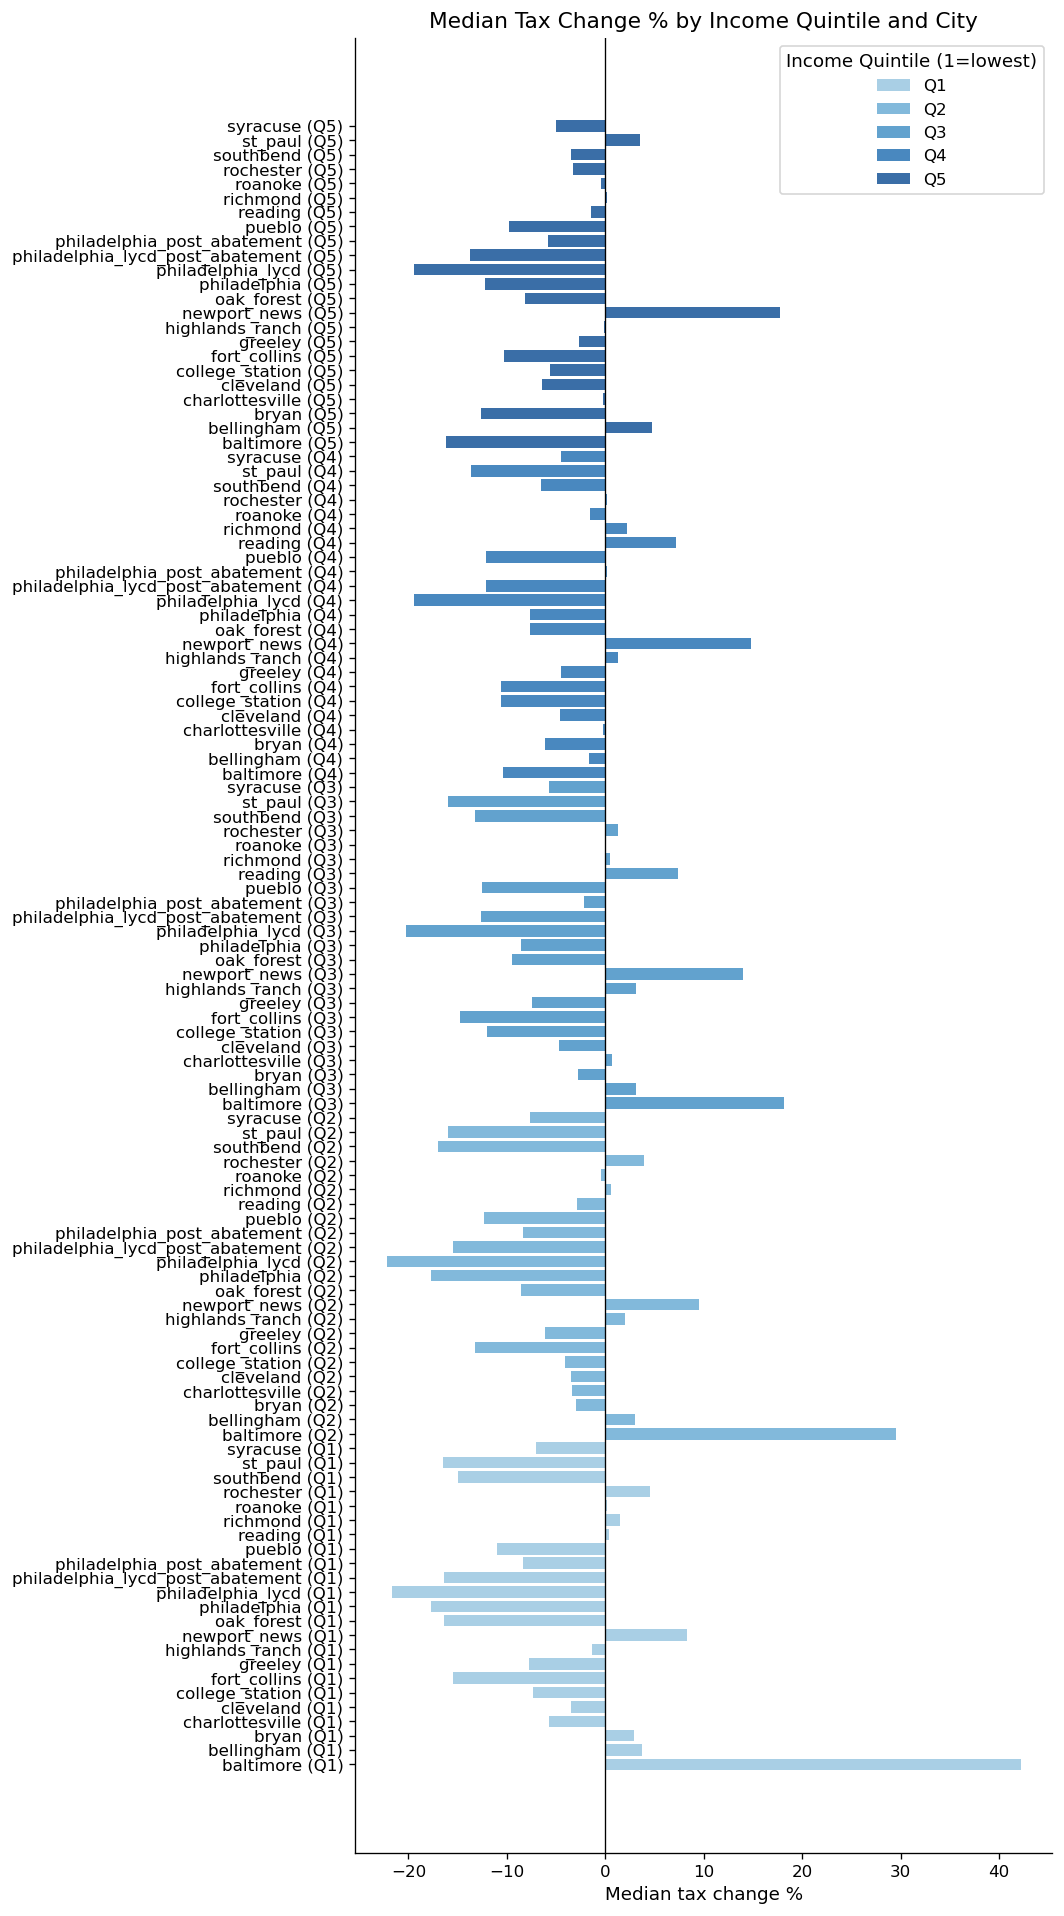

income_quintile                      1     2     3     4     5
city                                                          
baltimore                         42.2  29.5  18.2 -10.4 -16.2
bellingham                         3.7   3.0   3.1  -1.7   4.7
bryan                              2.9  -3.0  -2.8  -6.1 -12.6
charlottesville                   -5.7  -3.4   0.7  -0.2  -0.2
cleveland                         -3.5  -3.5  -4.7  -4.6  -6.4
college_station                   -7.3  -4.1 -12.0 -10.6  -5.6
fort_collins                     -15.5 -13.2 -14.8 -10.6 -10.3
greeley                           -7.7  -6.1  -7.4  -4.5  -2.7
highlands_ranch                   -1.3   2.0   3.1   1.3  -0.1
newport_news                       8.3   9.5  14.0  14.8  17.7
oak_forest                       -16.4  -8.6  -9.5  -7.6  -8.2
philadelphia                     -17.7 -17.7  -8.6  -7.6 -12.2
philadelphia_lycd                -21.7 -22.2 -20.2 -19.4 -19.4
philadelphia_lycd_post_abatement -16.4 -15.5 -12.6 -12.

In [5]:
# Income quintile analysis: median tax change % in each quintile, by city
# Only cities with Census data
with_census = all_cities[all_cities['median_income'].notna() & (all_cities['current_tax'] > 0)].copy()

if len(with_census) == 0:
    print('No Census data available yet. Run city notebooks with Census API key to populate.')
else:
    # Assign income quintile within each city
    with_census['income_quintile'] = with_census.groupby('city')['median_income'].transform(
        lambda x: pd.qcut(x, 5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    )

    quintile_city = (
        with_census.groupby(['city', 'income_quintile'])
        ['tax_change_pct']
        .median()
        .unstack('income_quintile')
        .round(1)
    )

    fig, ax = plt.subplots(figsize=(9, max(4, len(quintile_city) * 0.7)))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, 5))
    for q, color in zip([1, 2, 3, 4, 5], colors):
        if q in quintile_city.columns:
            ax.barh(
                [f'{c} (Q{q})' for c in quintile_city.index],
                quintile_city[q],
                label=f'Q{q}',
                color=color,
                alpha=0.8,
            )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Median tax change %')
    ax.set_title('Median Tax Change % by Income Quintile and City')
    ax.legend(title='Income Quintile (1=lowest)')
    plt.tight_layout()
    plt.show()

    print(quintile_city.to_string())

## 5. Minority Quintile Equity Comparison

In [6]:
# Minority quintile analysis: same structure as income quintile
with_census_m = all_cities[all_cities['minority_pct'].notna() & (all_cities['current_tax'] > 0)].copy()

if len(with_census_m) == 0:
    print('No Census minority data available yet.')
else:
    with_census_m['minority_quintile'] = with_census_m.groupby('city')['minority_pct'].transform(
        lambda x: pd.qcut(x, 5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    )

    min_quintile_city = (
        with_census_m.groupby(['city', 'minority_quintile'])
        ['tax_change_pct']
        .median()
        .unstack('minority_quintile')
        .round(1)
    )

    print('Median tax change % by minority quintile and city (Q1=least minority, Q5=most minority):')
    print(min_quintile_city.to_string())

Median tax change % by minority quintile and city (Q1=least minority, Q5=most minority):
minority_quintile                    1     2     3     4     5
city                                                          
baltimore                        -15.5  -7.8   2.1  35.7  45.3
bellingham                         7.6   5.1   0.7  -3.4   3.4
bryan                              0.4  -8.2  -7.7  -5.4   2.0
charlottesville                    0.4  -1.4  -0.7  -3.8  -1.7
cleveland                         -5.4  -4.7  -4.2  -3.1  -4.2
college_station                   -4.7 -12.6  -9.7 -10.3  -8.2
fort_collins                     -14.2 -12.1 -14.4 -11.5 -15.1
greeley                           -3.6  -4.5  -6.3  -7.6  -7.7
highlands_ranch                    1.4  -1.4   2.5   1.8   1.4
newport_news                      18.7  15.8  12.3  13.2   0.2
oak_forest                        -9.3  -9.8  -8.6  -9.5 -13.1
philadelphia                     -10.7 -10.4 -12.8 -17.7 -17.7
philadelphia_lycd            